# Exploratory Data Analysis of Premier League Player Statistics Season 2019-2020

This project explores Premier League player performance data using Python, Pandas, NumPy, and Matplotlib.

The main goals are to:
- examine the structure and quality of the dataset
- identify top-performing players
- compare player and team performance
- analyze relationships between shooting and scoring
- create basic performance metrics such as goals per 90 minutes

## Import Libraries

The libraries below are used for data manipulation, numerical analysis, and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load the Dataset

The dataset contains Premier League player statistics such as appearances, minutes played, goals, assists, shots, and shots on goal.

In [2]:
df = pd.read_csv(r"Premier League Player Stats.csv")
df.head(5)

,Rank,PLAYER,TEAM,GP,GS,MIN,G,ASST,SHOTS,SOG
0,1,Jamie Vardy,Leicester City,35,34,3034,23,5,71,43
1,2,Danny Ings,Southampton,38,32,2812,22,2,66,38
2,3,Pierre-Emerick Aubameyang,Arsenal,36,35,3138,22,3,70,42
3,4,Raheem Shaquille Sterling,Manchester City,33,30,2660,20,1,68,38
4,5,Mohamed Salah Ghaly,Liverpool,34,33,2884,19,10,95,59


## Dataset Overview

Before performing the analysis, the dataset is inspected to understand its size, variables, data types, and general statistical characteristics.

In [3]:
df.shape #number of rows and columns

(540, 10)

In [4]:
df.columns #columns names

Index(['Rank', 'PLAYER', 'TEAM', 'GP', 'GS', 'MIN', 'G', 'ASST', 'SHOTS',
       'SOG'],
      dtype='str')

In [5]:
df.info() #wdata types and non-null values

<class 'pandas.DataFrame'>
RangeIndex: 540 entries, 0 to 539
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Rank    540 non-null    int64
 1   PLAYER  540 non-null    str  
 2   TEAM    540 non-null    str  
 3   GP      540 non-null    int64
 4   GS      540 non-null    int64
 5   MIN     540 non-null    int64
 6   G       540 non-null    int64
 7   ASST    540 non-null    int64
 8   SHOTS   540 non-null    int64
 9   SOG     540 non-null    int64
dtypes: int64(8), str(2)
memory usage: 42.3 KB


In [6]:
df.describe().round(2) #summary statistics

,Rank,GP,GS,MIN,G,ASST,SHOTS,SOG
count,540.00,540.00,540.00,540.00,540.00,540.00,540.00,540.00
mean,270.50,18.99,15.09,1353.66,1.83,1.28,12.33,5.91
std,156.03,12.85,12.44,1091.59,3.55,2.13,16.65,9.25
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,135.75,7.00,2.00,241.50,0.00,0.00,0.00,0.00
50%,270.50,20.00,13.50,1219.50,0.00,0.00,6.00,2.00
75%,405.25,30.00,26.00,2295.50,2.00,2.00,17.00,7.00
max,540.00,38.00,38.00,3420.00,23.00,20.00,95.00,59.00


### Initial Observations

- The dataset contains 540 players and 10 columns.
- `PLAYER` and `TEAM` are categorical variables, while the remaining columns are numerical.
- No missing values are detected because all columns contain 540 non-null entries.
- The average player made about 19 appearances and played approximately 1,354 minutes.

## Data Cleaning

The dataset is checked for missing values, duplicate records, and unusual values before further analysis.

### Missing values

In [7]:
df.isnull().sum()

Rank      0
PLAYER    0
TEAM      0
GP        0
GS        0
MIN       0
G         0
ASST      0
SHOTS     0
SOG       0
dtype: int64

No missing values

### Duplicate Records

Duplicate rows are checked to ensure that the same player record is not counted more than once.

In [8]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
535    False
536    False
537    False
538    False
539    False
Length: 540, dtype: bool

### Players with Zero Minutes

Players with zero minutes played are identified because they may affect calculations such as goals per 90 minutes.

In [9]:
df[df['MIN'] == 0]

,Rank,PLAYER,TEAM,GP,GS,MIN,G,ASST,SHOTS,SOG
282,283,David Button,Brighton and Hove Albion,0,0,0,0,0,0,0
295,296,Artur Boruc,Bournemouth,0,0,0,0,0,0,0
340,341,John Ruddy,Wolverhampton Wanderers,0,0,0,0,0,0,0
343,344,Danny Ward,Leicester City,0,0,0,0,0,0,0
345,346,Karl Darlow,Newcastle United,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
534,535,Josh Benson,Burnley,0,0,0,0,0,0,0
535,536,Dennis Cirkin,Tottenham Hotspur,0,0,0,0,0,0,0
536,537,Darnell Johnson,Leicester City,0,0,0,0,0,0,0
538,539,Conor Coventry,West Ham United,0,0,0,0,0,0,0


In [10]:
(df["MIN"] == 0).sum()

np.int64(70)

### Players with Zero Minutes

There are 70 players with zero minutes played. These players are kept in the dataset for general analysis but should be excluded or handled carefully when calculating per-90-minute statistics.

## Descriptive Statistics

Basic summary statistics are calculated to better understand the overall distribution of player performance.

### Average goals

In [11]:
df["G"].mean().round(2)

np.float64(1.83)

### Median goals

In [12]:
df["G"].median().round(2)

np.float64(0.0)

### Average Assists

In [13]:
df["ASST"].mean().round(2)

np.float64(1.28)

### Average shots

In [14]:
df["SHOTS"].mean().round(2)

np.float64(12.33)

### Maximum Goals

In [15]:
df["G"].max()

np.int64(23)

### Observations

- The average player scored 1.83 goals, while the median number of goals was 0.
- This suggests that many players scored few or no goals, while a smaller number of players scored much more frequently.
- The average player recorded 1.28 assists and 12.33 shots.
- The highest goal total in the dataset was 23.

## Top Player Analysis

This section identifies the top-performing players based on goals, assists, shots, and shots on goal.

### Top 10 Goal Scorers

In [16]:
top_scorers = df.sort_values("G", ascending = False).head(10)
top_scorers[["PLAYER","TEAM","G"]]

,PLAYER,TEAM,G
0,Jamie Vardy,Leicester City,23
1,Danny Ings,Southampton,22
2,Pierre-Emerick Aubameyang,Arsenal,22
3,Raheem Shaquille Sterling,Manchester City,20
4,Mohamed Salah Ghaly,Liverpool,19
5,Sadio Mané,Liverpool,18
6,Harry Kane,Tottenham Hotspur,18
7,Raúl Alonso Jiménez Rodríguez,Wolverhampton Wanderers,17
8,Marcus Rashford,Manchester United,17
9,Anthony Martial,Manchester United,17


### Observation

Jamie Vardy was the top goal scorer with 23 goals. Danny Ings and Pierre-Emerick Aubameyang followed with 22 goals each.

### Top 10 Assists

In [17]:
top_assists = df.sort_values("ASST", ascending = False).head(10).reset_index(drop = True)
top_assists[["PLAYER","TEAM","ASST"]]

,PLAYER,TEAM,ASST
0,Kevin De Bruyne,Manchester City,20
1,Trent Alexander-Arnold,Liverpool,13
2,Andrew Robertson,Liverpool,12
3,David Silva,Manchester City,10
4,Heung-Min Son,Tottenham Hotspur,10
5,Mohamed Salah Ghaly,Liverpool,10
6,Riyad Mahrez,Manchester City,9
7,Adama Traoré,Wolverhampton Wanderers,9
8,Harvey Barnes,Leicester City,8
9,Roberto Firmino Barbosa de Oliveira,Liverpool,8


### Observation

Kevin De Bruyne recorded the most assists with 20, followed by Trent Alexander-Arnold with 13 and Andrew Robertson with 12.

### Top 10 shots

In [18]:
top_shots = df.sort_values("SHOTS", ascending = False).head(10).reset_index(drop = True)
top_shots[["PLAYER","TEAM","SHOTS"]]

,PLAYER,TEAM,SHOTS
0,Mohamed Salah Ghaly,Liverpool,95
1,Raúl Alonso Jiménez Rodríguez,Wolverhampton Wanderers,89
2,Gabriel Fernando de Jesus,Manchester City,81
3,Marcus Rashford,Manchester United,77
4,Tammy Bakumo-Abraham,Chelsea,74
5,Jamie Vardy,Leicester City,71
6,Pierre-Emerick Aubameyang,Arsenal,70
7,Kevin De Bruyne,Manchester City,70
8,Dominic Calvert-Lewin,Everton,70
9,Roberto Firmino Barbosa de Oliveira,Liverpool,70


### Observation

Mohamed Salah recorded the most shots with 95, followed by Raúl Jiménez with 89 and Gabriel Jesus with 81.

### Top 10 Players by Shots on Goal

In [19]:
top_sog = df.sort_values("SOG", ascending = False).head(10).reset_index(drop = True)
top_sog[["PLAYER","TEAM","SOG"]]

,PLAYER,TEAM,SOG
0,Mohamed Salah Ghaly,Liverpool,59
1,Gabriel Fernando de Jesus,Manchester City,48
2,Marcus Rashford,Manchester United,44
3,Raúl Alonso Jiménez Rodríguez,Wolverhampton Wanderers,44
4,Jamie Vardy,Leicester City,43
5,Pierre-Emerick Aubameyang,Arsenal,42
6,Anthony Martial,Manchester United,40
7,Tammy Bakumo-Abraham,Chelsea,40
8,Roberto Firmino Barbosa de Oliveira,Liverpool,39
9,Heung-Min Son,Tottenham Hotspur,38


### Observation

Mohamed Salah recorded the most shots on goal with 59, followed by Gabriel Jesus with 48. Marcus Rashford and Raúl Jiménez both recorded 44 shots on goal.

## Creating Performance Metrics

Raw totals can favor players who have played more minutes. To make player comparisons more meaningful, additional performance metrics are created.

### Goals per 90 Minutes

Goals per 90 minutes measures scoring rate while accounting for differences in playing time.

Players with zero minutes played are assigned a value of 0 to avoid division by zero.

In [20]:
df["G_PER_90"] = np.where(df["MIN"] == 0, 0 , ((df["G"] / df["MIN"]) * 90).round(2))
df

,Rank,PLAYER,TEAM,GP,GS,MIN,G,ASST,SHOTS,SOG,G_PER_90
0,1,Jamie Vardy,Leicester City,35,34,3034,23,5,71,43,0.68
1,2,Danny Ings,Southampton,38,32,2812,22,2,66,38,0.70
2,3,Pierre-Emerick Aubameyang,Arsenal,36,35,3138,22,3,70,42,0.63
3,4,Raheem Shaquille Sterling,Manchester City,33,30,2660,20,1,68,38,0.68
4,5,Mohamed Salah Ghaly,Liverpool,34,33,2884,19,10,95,59,0.59
...,...,...,...,...,...,...,...,...,...,...,...
535,536,Dennis Cirkin,Tottenham Hotspur,0,0,0,0,0,0,0,0.00
536,537,Darnell Johnson,Leicester City,0,0,0,0,0,0,0,0.00
537,538,Timothy Fosu-Mensah,Manchester United,3,2,136,0,0,1,0,0.00
538,539,Conor Coventry,West Ham United,0,0,0,0,0,0,0,0.00


### Assists per 90 Minutes

Assists per 90 minutes measures assisting rate while accounting for differences in playing time.

Players with zero minutes played are assigned a value of 0 to avoid division by zero.

In [21]:
df["ASST_PER_90"] = np.where(df["MIN"] == 0, 0 , ((df["ASST"] / df["MIN"]) * 90).round(2))
df

,Rank,PLAYER,TEAM,GP,GS,MIN,G,ASST,SHOTS,SOG,G_PER_90,ASST_PER_90
0,1,Jamie Vardy,Leicester City,35,34,3034,23,5,71,43,0.68,0.15
1,2,Danny Ings,Southampton,38,32,2812,22,2,66,38,0.70,0.06
2,3,Pierre-Emerick Aubameyang,Arsenal,36,35,3138,22,3,70,42,0.63,0.09
3,4,Raheem Shaquille Sterling,Manchester City,33,30,2660,20,1,68,38,0.68,0.03
4,5,Mohamed Salah Ghaly,Liverpool,34,33,2884,19,10,95,59,0.59,0.31
...,...,...,...,...,...,...,...,...,...,...,...,...
535,536,Dennis Cirkin,Tottenham Hotspur,0,0,0,0,0,0,0,0.00,0.00
536,537,Darnell Johnson,Leicester City,0,0,0,0,0,0,0,0.00,0.00
537,538,Timothy Fosu-Mensah,Manchester United,3,2,136,0,0,1,0,0.00,0.00
538,539,Conor Coventry,West Ham United,0,0,0,0,0,0,0,0.00,0.00


### Shots per 90 Minutes

Shots per 90 minutes measures how frequently a player attempts shots while accounting for differences in playing time.

In [22]:
df["SHOTS_PER_90"] = np.where(df["MIN"] == 0, 0 , ((df["SHOTS"] / df["MIN"]) * 90).round(2))
df

,Rank,PLAYER,TEAM,GP,GS,MIN,G,ASST,SHOTS,SOG,G_PER_90,ASST_PER_90,SHOTS_PER_90
0,1,Jamie Vardy,Leicester City,35,34,3034,23,5,71,43,0.68,0.15,2.11
1,2,Danny Ings,Southampton,38,32,2812,22,2,66,38,0.70,0.06,2.11
2,3,Pierre-Emerick Aubameyang,Arsenal,36,35,3138,22,3,70,42,0.63,0.09,2.01
3,4,Raheem Shaquille Sterling,Manchester City,33,30,2660,20,1,68,38,0.68,0.03,2.30
4,5,Mohamed Salah Ghaly,Liverpool,34,33,2884,19,10,95,59,0.59,0.31,2.96
...,...,...,...,...,...,...,...,...,...,...,...,...,...
535,536,Dennis Cirkin,Tottenham Hotspur,0,0,0,0,0,0,0,0.00,0.00,0.00
536,537,Darnell Johnson,Leicester City,0,0,0,0,0,0,0,0.00,0.00,0.00
537,538,Timothy Fosu-Mensah,Manchester United,3,2,136,0,0,1,0,0.00,0.00,0.66
538,539,Conor Coventry,West Ham United,0,0,0,0,0,0,0,0.00,0.00,0.00


### Shot Accuracy

Shot accuracy measures the proportion of a player's total shots that were on target.

In [23]:
df["SHOT_ACCURACY"] = np.where(df["SHOTS"] == 0, 0 , ((df["SOG"] / df["SHOTS"])).round(2))
df

,Rank,PLAYER,TEAM,GP,GS,MIN,G,ASST,SHOTS,SOG,G_PER_90,ASST_PER_90,SHOTS_PER_90,SHOT_ACCURACY
0,1,Jamie Vardy,Leicester City,35,34,3034,23,5,71,43,0.68,0.15,2.11,0.61
1,2,Danny Ings,Southampton,38,32,2812,22,2,66,38,0.70,0.06,2.11,0.58
2,3,Pierre-Emerick Aubameyang,Arsenal,36,35,3138,22,3,70,42,0.63,0.09,2.01,0.60
3,4,Raheem Shaquille Sterling,Manchester City,33,30,2660,20,1,68,38,0.68,0.03,2.30,0.56
4,5,Mohamed Salah Ghaly,Liverpool,34,33,2884,19,10,95,59,0.59,0.31,2.96,0.62
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
535,536,Dennis Cirkin,Tottenham Hotspur,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00
536,537,Darnell Johnson,Leicester City,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00
537,538,Timothy Fosu-Mensah,Manchester United,3,2,136,0,0,1,0,0.00,0.00,0.66,0.00
538,539,Conor Coventry,West Ham United,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00


### Goal Conversion Rate

Goal conversion rate measures the proportion of a player's total shots that resulted in goals.

In [24]:
df["GOAL_CONVERSION"] = np.where(df["SHOTS"] == 0, 0 , ((df["G"] / df["SHOTS"])).round(2))
df

,Rank,PLAYER,TEAM,GP,GS,MIN,G,ASST,SHOTS,SOG,G_PER_90,ASST_PER_90,SHOTS_PER_90,SHOT_ACCURACY,GOAL_CONVERSION
0,1,Jamie Vardy,Leicester City,35,34,3034,23,5,71,43,0.68,0.15,2.11,0.61,0.32
1,2,Danny Ings,Southampton,38,32,2812,22,2,66,38,0.70,0.06,2.11,0.58,0.33
2,3,Pierre-Emerick Aubameyang,Arsenal,36,35,3138,22,3,70,42,0.63,0.09,2.01,0.60,0.31
3,4,Raheem Shaquille Sterling,Manchester City,33,30,2660,20,1,68,38,0.68,0.03,2.30,0.56,0.29
4,5,Mohamed Salah Ghaly,Liverpool,34,33,2884,19,10,95,59,0.59,0.31,2.96,0.62,0.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
535,536,Dennis Cirkin,Tottenham Hotspur,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00
536,537,Darnell Johnson,Leicester City,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00
537,538,Timothy Fosu-Mensah,Manchester United,3,2,136,0,0,1,0,0.00,0.00,0.66,0.00,0.00
538,539,Conor Coventry,West Ham United,0,0,0,0,0,0,0,0.00,0.00,0.00,0.00,0.00


### Observation

Danny Ings had a slightly higher goal conversion rate than Jamie Vardy, while Mohamed Salah took more shots but converted a smaller proportion of them into goals.

## Filtering Players for Fair Comparison

Players with very limited playing time may have misleading per-90 statistics. A minimum playing-time threshold is applied to make player comparisons more reliable.

In [25]:
qualified_players = df[df["MIN"] >= 1500]

In [26]:
qualified_players.shape

(234, 15)

After applying the 1,500-minute threshold, 234 players remain for the efficiency analysis.

## Player Efficiency Analysis

Qualified players are compared using per-90-minute and shooting-efficiency metrics rather than raw totals alone.

### Top 10 Goals per 90

In [27]:
top_goals_per_90 = qualified_players.sort_values("G_PER_90", ascending = False).head(10).reset_index(drop = True)
top_goals_per_90[["PLAYER","TEAM","MIN","G","G_PER_90"]]

,PLAYER,TEAM,MIN,G,G_PER_90
0,Danny Ings,Southampton,2812,22,0.70
1,Jamie Vardy,Leicester City,3034,23,0.68
2,Raheem Shaquille Sterling,Manchester City,2660,20,0.68
3,Pierre-Emerick Aubameyang,Arsenal,3138,22,0.63
4,Harry Kane,Tottenham Hotspur,2589,18,0.63
5,Gabriel Fernando de Jesus,Manchester City,2027,14,0.62
6,Tammy Bakumo-Abraham,Chelsea,2221,15,0.61
7,Mohamed Salah Ghaly,Liverpool,2884,19,0.59
8,Sadio Mané,Liverpool,2753,18,0.59
9,Marcus Rashford,Manchester United,2653,17,0.58


### Observation

Danny Ings had the highest goals-per-90 rate among players with at least 1,500 minutes, averaging 0.70 goals per 90 minutes. Jamie Vardy and Raheem Sterling followed closely at 0.68.

### Top 10 Assists per 90

In [28]:
top_assists_per_90 = qualified_players.sort_values("ASST_PER_90", ascending = False).head(10).reset_index(drop = True)
top_assists_per_90[["PLAYER","TEAM","MIN","ASST","ASST_PER_90"]]

,PLAYER,TEAM,MIN,ASST,ASST_PER_90
0,Kevin De Bruyne,Manchester City,2798,20,0.64
1,David Silva,Manchester City,1832,10,0.49
2,Riyad Mahrez,Manchester City,1940,9,0.42
3,Trent Alexander-Arnold,Liverpool,3176,13,0.37
4,Heung-Min Son,Tottenham Hotspur,2485,10,0.36
5,Andrew Robertson,Liverpool,3113,12,0.35
6,Harvey Barnes,Leicester City,2090,8,0.34
7,Mohamed Salah Ghaly,Liverpool,2884,10,0.31
8,Gabriel Fernando de Jesus,Manchester City,2027,7,0.31
9,Bernardo Mota Veiga de Carvalho e Silva,Manchester City,2029,7,0.31


### Top 10 Players by Shot Accuracy

To make the comparison more reliable, only qualified players with at least 40 total shots are included.

In [29]:
top_shot_accuracy = qualified_players[qualified_players["SHOTS"] >= 40].sort_values("SHOT_ACCURACY", ascending = False).head(10).reset_index(drop = True)
top_shot_accuracy[["PLAYER","TEAM","MIN","SHOTS","SOG","SHOT_ACCURACY"]]

,PLAYER,TEAM,MIN,SHOTS,SOG,SHOT_ACCURACY
0,Anthony Martial,Manchester United,2638,59,40,0.68
1,Riyad Mahrez,Manchester City,1940,51,32,0.63
2,Teemu Pukki,Norwich City,2892,56,35,0.62
3,Mohamed Salah Ghaly,Liverpool,2884,95,59,0.62
4,Jamie Vardy,Leicester City,3034,71,43,0.61
5,Heung-Min Son,Tottenham Hotspur,2485,62,38,0.61
6,Harvey Barnes,Leicester City,2090,46,28,0.61
7,Harry Kane,Tottenham Hotspur,2589,62,37,0.60
8,Pierre-Emerick Aubameyang,Arsenal,3138,70,42,0.60
9,James Ward-Prowse,Southampton,3420,43,26,0.60


### Observation

Anthony Martial had the highest shot accuracy among qualified shooters at 0.68. Riyad Mahrez followed at 0.63, while Teemu Pukki and Mohamed Salah both recorded a shot accuracy of 0.62.

### Top 10 Goal Conversion Rate

In [30]:
top_goal_conversion = qualified_players[qualified_players["SHOTS"] >= 40].sort_values("GOAL_CONVERSION", ascending = False).head(10).reset_index(drop = True)
top_goal_conversion[["PLAYER","TEAM","MIN","G","SHOTS","GOAL_CONVERSION"]]

,PLAYER,TEAM,MIN,G,SHOTS,GOAL_CONVERSION
0,Danny Ings,Southampton,2812,22,66,0.33
1,Jamie Vardy,Leicester City,3034,23,71,0.32
2,Pierre-Emerick Aubameyang,Arsenal,3138,22,70,0.31
3,Raheem Shaquille Sterling,Manchester City,2660,20,68,0.29
4,Harry Kane,Tottenham Hotspur,2589,18,62,0.29
5,Anthony Martial,Manchester United,2638,17,59,0.29
6,Sadio Mané,Liverpool,2753,18,66,0.27
7,Chris Wood,Burnley,2444,14,57,0.25
8,Alexandre Lacazette,Arsenal,1877,10,44,0.23
9,Marcus Rashford,Manchester United,2653,17,77,0.22


Although some players attempted more shots, Danny Ings converted a higher proportion of his attempts into goals.

## Team-Level Analysis

Player statistics are grouped by team to compare overall attacking performance across Premier League clubs.

### Total Goals by Team

In [31]:
total_goals_by_team = df.groupby("TEAM")["G"].sum().reset_index().sort_values("G", ascending = False).reset_index(drop = True)
total_goals_by_team

,TEAM,G
0,Manchester City,100
1,Liverpool,83
2,Chelsea,69
3,Leicester City,65
4,Manchester United,65
5,Arsenal,56
6,Tottenham Hotspur,54
7,Southampton,51
8,West Ham United,48
9,Wolverhampton Wanderers,47


### Observation

Manchester City recorded the highest total number of goals with 100, followed by Liverpool with 83 and Chelsea with 69.

### Total Assists by Team

In [32]:
total_assists_by_team = df.groupby("TEAM")["ASST"].sum().reset_index().sort_values("ASST", ascending = False).reset_index(drop = True)
total_assists_by_team

,TEAM,ASST
0,Liverpool,69
1,Manchester City,69
2,Leicester City,47
3,Chelsea,46
4,Manchester United,43
5,West Ham United,36
6,Arsenal,36
7,Tottenham Hotspur,35
8,Wolverhampton Wanderers,34
9,Everton,32


### Observation

Liverpool and Manchester City recorded the highest total number of assists with 69 each, followed by Leicester City with 47 and Chelsea with 46.

### Total Shots by Team

In [33]:
total_shots_by_team = df.groupby("TEAM")["SHOTS"].sum().reset_index().sort_values("SHOTS", ascending = False).reset_index(drop = True)
total_shots_by_team

,TEAM,SHOTS
0,Manchester City,519
1,Chelsea,447
2,Liverpool,428
3,Manchester United,413
4,Leicester City,398
5,Southampton,360
6,Everton,337
7,Aston Villa,335
8,West Ham United,319
9,Wolverhampton Wanderers,316


### Observation

Manchester City recorded the highest total number of shots with 519, followed by Chelsea with 447 and Liverpool with 428.

In [34]:
top_scorer_each_team = df.sort_values("G", ascending = False).drop_duplicates(subset = ["TEAM"]).sort_values("TEAM").reset_index(drop = True).set_index("TEAM")
top_scorer_each_team[["PLAYER","G"]]

,PLAYER,G
TEAM,,
Arsenal,Pierre-Emerick Aubameyang,22
Aston Villa,Jack Grealish,8
Bournemouth,Callum Wilson,8
Brighton and Hove Albion,Neal Maupay,10
Burnley,Chris Wood,14
Chelsea,Tammy Bakumo-Abraham,15
Crystal Palace,Jordan Ayew,9
Everton,Dominic Calvert-Lewin,13
Leicester City,Jamie Vardy,23


In [35]:
top_assist_each_team = df.sort_values("ASST", ascending = False).drop_duplicates(subset = ["TEAM"]).sort_values("TEAM").reset_index(drop = True).set_index("TEAM")
top_assist_each_team[["PLAYER","ASST"]]

,PLAYER,ASST
TEAM,,
Arsenal,Nicolas Pépé,6
Aston Villa,Jack Grealish,6
Bournemouth,Diego Rico,4
Brighton and Hove Albion,Pascal Groß,4
Burnley,Dwight McNeil,6
Chelsea,Willian Borges Da Silva,7
Crystal Palace,James McArthur,3
Everton,Lucas Digne,7
Leicester City,Harvey Barnes,8


## Data Visualization

Visualizations are used to explore distributions, compare top performers, and examine relationships between key performance variables.

### Distribution of Goals

A histogram is used to examine how goals are distributed across Premier League players.

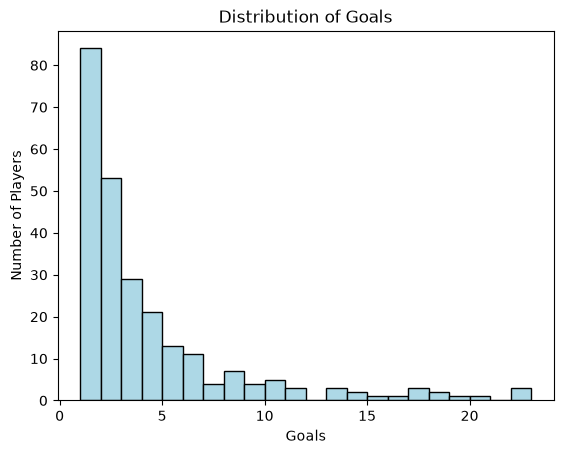

In [36]:
plt.hist(df["G"], bins = np.arange(1,24), color = "lightblue", edgecolor = "black")
plt.title("Distribution of Goals")
plt.ylabel("Number of Players")
plt.xlabel("Goals")
plt.show()

### Observation

The distribution of goals is strongly right-skewed. Most players scored few or no goals, while only a small number of players recorded high goal totals.

### Top 10 Goal Scorers

A horizontal bar chart is used to compare the ten players with the highest goal totals.

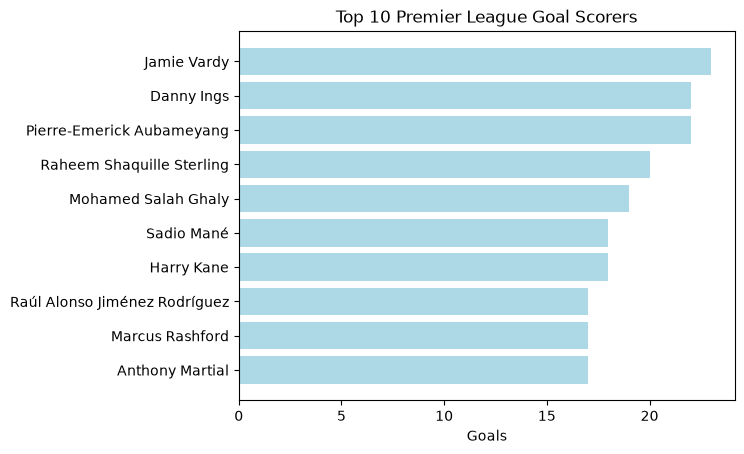

In [37]:
plt.barh(top_scorers["PLAYER"], top_scorers["G"], color = "lightblue")
plt.title("Top 10 Premier League Goal Scorers")
plt.xlabel("Goals")
plt.gca().invert_yaxis()
plt.show()

### Observation

Jamie Vardy was the leading scorer with 23 goals, followed by Danny Ings and Pierre-Emerick Aubameyang with 22 goals each.

### Relationship Between Shots and Goals

A scatter plot is used to examine whether players who take more shots also tend to score more goals.

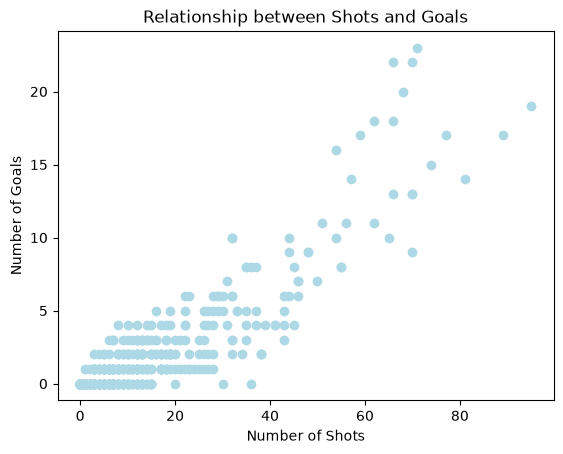

In [38]:
plt.scatter(df["SHOTS"], df["G"],color = "lightblue")
plt.ylabel("Number of Goals")
plt.xlabel("Number of Shots")
plt.title("Relationship between Shots and Goals")
plt.show()

### Observation

The scatter plot shows a clear positive relationship between shots and goals. Players who attempted more shots generally tended to score more goals.

However, players with similar shot totals sometimes recorded different goal totals, suggesting that shooting efficiency also affects scoring performance.

### Relationship Between Shots on Goal and Goals

A scatter plot is used to examine whether shots on goal have a stronger relationship with goals than total shot attempts.

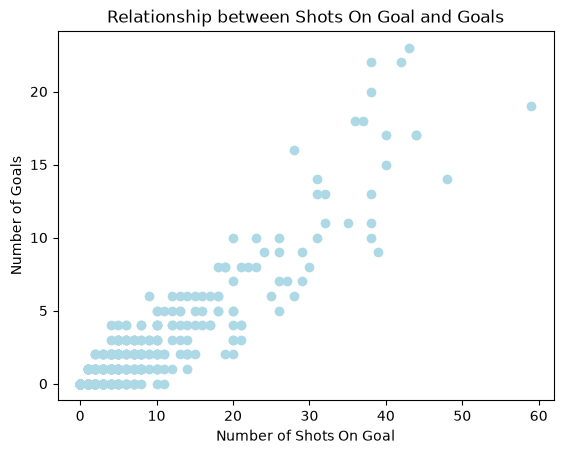

In [39]:
plt.scatter(df["SOG"], df["G"],color = "lightblue")
plt.ylabel("Number of Goals")
plt.xlabel("Number of Shots On Goal")
plt.title("Relationship between Shots On Goal and Goals")
plt.show()

### Observation

The scatter plot shows a strong positive relationship between shots on goal and goals. Players with more shots on target generally scored more goals.

Compared with total shots, shots on goal appear to have a stronger relationship with goals, suggesting that shot accuracy is an important factor in scoring performance.

### Total Goals by Team

A bar chart is used to compare total goal output across Premier League teams.

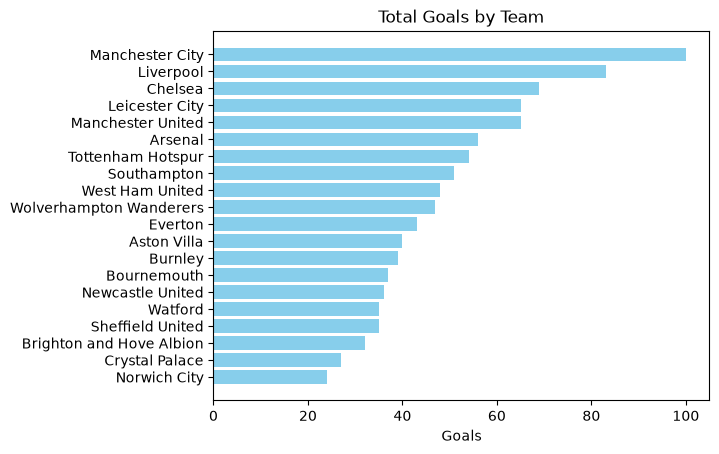

In [40]:
plt.barh(total_goals_by_team["TEAM"], total_goals_by_team["G"], color = "skyblue")
plt.title("Total Goals by Team")
plt.xlabel("Goals")
plt.gca().invert_yaxis()
plt.show()

### Observation

Manchester City recorded the highest total number of goals, followed by Liverpool and Chelsea.

The gap between Manchester City and the other teams suggests that they had the strongest overall attacking output in the dataset.

### Total Shots by Team

A horizontal bar chart is used to compare the total number of shots taken by each Premier League team.

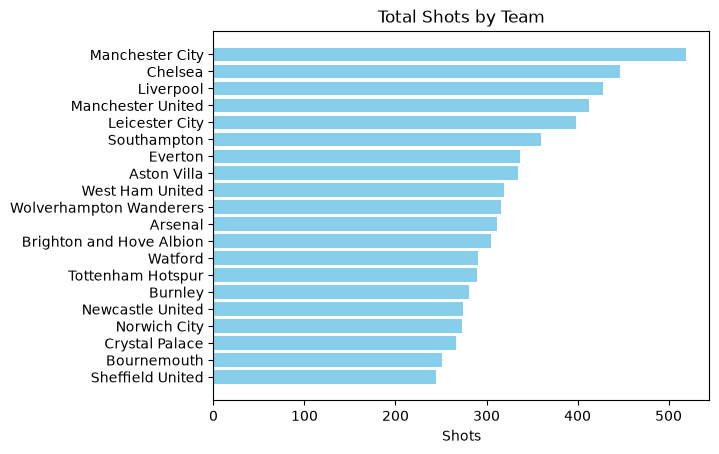

In [41]:
plt.barh(total_shots_by_team["TEAM"], total_shots_by_team["SHOTS"], color = "skyblue")
plt.title("Total Shots by Team")
plt.xlabel("Shots")
plt.gca().invert_yaxis()
plt.show()

### Observation

Manchester City recorded the highest total number of shots, with slightly more than 500 shots. Chelsea and Liverpool ranked second and third, while Sheffield United had the fewest shots. Overall, the chart shows a considerable difference in attacking output between the highest- and lowest-ranked teams.

## Key Findings

- The distribution of goals is strongly right-skewed, with most players scoring few or no goals.
- Players who attempted more shots generally tended to score more goals.
- Shots on goal showed a strong positive relationship with goals.
- Danny Ings had the highest goals-per-90 rate among players with at least 1,500 minutes played.
- Kevin De Bruyne had the highest assists-per-90 rate among qualified players.
- Manchester City recorded the highest total number of goals and shots among Premier League teams.

## Conclusion

This exploratory data analysis examined Premier League player performance using Python, Pandas, NumPy, and Matplotlib.

The analysis included data cleaning, descriptive statistics, player rankings, per-90 performance metrics, shooting efficiency, team-level comparisons, and data visualization.

The results show that shot volume and shots on goal are positively associated with scoring, while per-90 metrics provide a fairer way to compare players with different amounts of playing time.

Overall, this project demonstrates how basic data analysis techniques can be applied to football performance data to identify meaningful trends and player performance patterns.